# Plot velocity quivers map from moms data

Works with jupyterlab3 on ppmstar.org

In [ ]:
%pylab ipympl

In [16]:
from ppmpy import ppm
import os

In [17]:
# set cycling combination of color-blind labels, glyphs, styles
lll= 2*['-', '--', ':', '-.']
markers = ['X','h','<','>','s','^','d','X','p']
random.shuffle(lll)
CB_color_cycle = ['#4daf4a', '#a65628', '#984ea3',
                  '#ff7f00', '#f781bf', '#377eb8',
                  '#999999', '#e41a1c', '#dede00']
rc('axes', prop_cycle=(cycler('color', CB_color_cycle[0:8]) + cycler('marker',markers[0:8])+cycler('linestyle',lll)))
rc('axes', prop_cycle=(cycler('color', CB_color_cycle[0:8]) +cycler('linestyle',lll)))

# named tuple for using rprofs and momsdata
# moms data are almost always used alongside rprof data and therefore it is recommended 
# to create a convenient dictionary that will hold the rprof and moms instance 
import collections
hydro = collections.namedtuple('hydro', ['moms','rprof'])

# turn off matplotlib messages
logging.getLogger("matplotlib").setLevel(logging.CRITICAL)

In [18]:
# the list of variables that are stored within the momsdata cube.
var_list = ['vort','ur','ut','ux','uz','6','7','8','9','rho']

In [19]:
# dump_select = 400 
# data_dir = '/home/user/user/niagara_scratch_fherwig/'
# run_dir = 'X37-1xL-768-mc12400-rot-77kms-at-1100Mm'
# res=768

dump_select = 700
data_dir = '/home/user/user/frontera_scratch3_pwoodwar/'
run_dir = 'X38-Texascale-1xL-mc12400-rot-77kms-at-1100Mm'
res=1536

In [20]:
moms_dir = os.path.join(data_dir,run_dir,'moms/myavsbq')
rprof_dir = os.path.join(data_dir,run_dir,'prfs')
# load moms instance
dump = dump_select
moms = ppm.MomsDataSet(moms_dir,init_dump_read=dump,dumps_in_mem=1,var_list=var_list,rprofset=ppm.RprofSet(rprof_dir))
run = hydro(moms,  ppm.RprofSet(rprof_dir))

595 rprof files found in '/home/user/user/niagara_scratch_fherwig/X37-1xL-768-mc12400-rot-77kms-at-1100Mm/prfs/.
Dump numbers range from 0 to 594.
196 .aaa files found in '/home/user/user/niagara_scratch_fherwig/X37-1xL-768-mc12400-rot-77kms-at-1100Mm/moms/myavsbq/.
Dump numbers range from 0 to 600.
595 rprof files found in '/home/user/user/niagara_scratch_fherwig/X37-1xL-768-mc12400-rot-77kms-at-1100Mm/prfs/.
Dump numbers range from 0 to 594.


In [21]:
ut = run.moms.get('ut')
ur = run.moms.get('ur')
ux = run.moms.get('ux')
# uy = run.moms.get('uy')
uz = run.moms.get('uz')
rho = run.moms.get('rho')
x,y,z = run.moms.get_cgrid()

In [22]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return array[idx]

In [23]:
from matplotlib.colors import SymLogNorm, LogNorm

In [24]:
matplotlib.rcParams.update({'font.size': 16})

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:25: RuntimeWarning: invalid value encountered in true_divide
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:26: RuntimeWarning: invalid value encountered in true_divide


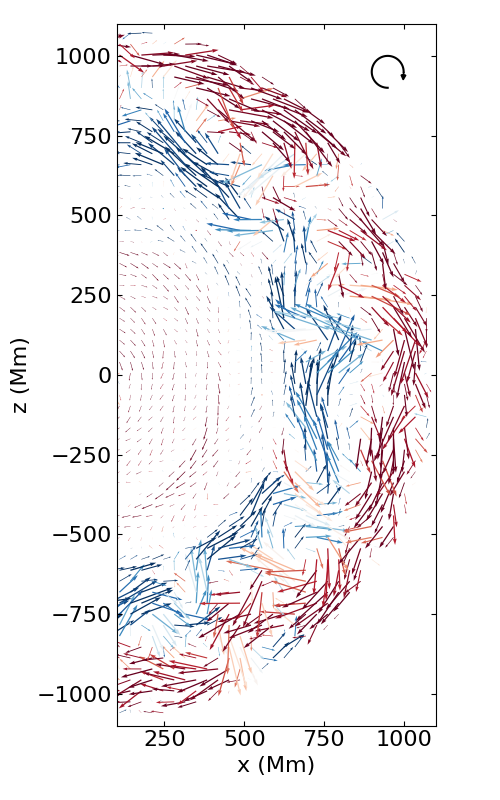

In [35]:
fig, ax1 = plt.subplots(1, 1, figsize=(5, 8))
# Left panel (x-z plane) -------------------------
ycut = find_nearest(np.unique(y), 0)
xplot = np.unique(x[y==ycut])
zplot = np.unique(z[y==ycut])
ux_plot_xz = np.reshape(ux[y==ycut], (int(res/4),int(res/4)))
uz_plot_xz = np.reshape(uz[y==ycut], (int(res/4),int(res/4)))

# Create coordinate arrays for calculating expected azimuthal direction
X_full, Z_full = np.meshgrid(xplot, zplot)
# Calculate center point (assuming this is the rotation center)
x_center = 0  
z_center = 0  

# Calculate the expected azimuthal unit vectors for perfect rotation
r_x = X_full - x_center
r_z = Z_full - z_center
r_mag = np.sqrt(r_x**2 + r_z**2)
# Unit vectors for perfect counterclockwise rotation
phi_x = -r_z / r_mag
phi_z = r_x / r_mag

# Calculate actual velocity directions
v_mag = np.sqrt(ux_plot_xz**2 + uz_plot_xz**2)
v_x = ux_plot_xz / v_mag
v_z = uz_plot_xz / v_mag

# Calculate alignment with perfect rotation (-1 for clockwise, +1 for counterclockwise)
alignment = v_x * phi_x + v_z * phi_z

# Apply Gaussian filter for smoother velocity field
from scipy.ndimage import gaussian_filter
sigma = 1  # Filter width - adjust as needed
ux_smooth = gaussian_filter(ux_plot_xz, sigma)
uz_smooth = gaussian_filter(uz_plot_xz, sigma)

# Velocity magnitude mask with smoothed fields
velocity_mask_xz = (np.abs(ux_smooth) > 1e-4) | (np.abs(uz_smooth) > 1e-4)

# Create grid with desired spacing
spacing = 3  # Adjust this value to control arrow density
x_idx = np.arange(0, ux_smooth.shape[0], spacing)
z_idx = np.arange(0, ux_smooth.shape[1], spacing)
X, Z = np.meshgrid(xplot[x_idx], zplot[z_idx])

# Sample the smoothed velocity fields
ux_masked = ux_smooth[np.ix_(x_idx, z_idx)][velocity_mask_xz[np.ix_(x_idx, z_idx)]]
uz_masked = uz_smooth[np.ix_(x_idx, z_idx)][velocity_mask_xz[np.ix_(x_idx, z_idx)]]
alignment_masked = alignment[np.ix_(x_idx, z_idx)][velocity_mask_xz[np.ix_(x_idx, z_idx)]]
X_masked = X[velocity_mask_xz[np.ix_(x_idx, z_idx)]]
Z_masked = Z[velocity_mask_xz[np.ix_(x_idx, z_idx)]]

# Create quiver plot with colors based on alignment
q = ax1.quiver(X_masked, Z_masked, 
               ux_masked, uz_masked,
               alignment_masked,  # Color by alignment with perfect rotation
               cmap='RdBu',      # Red for clockwise, Blue for counterclockwise
               scale=0.03,
               width=0.004,
               headwidth=3,
               headlength=5,
               headaxislength=4.5,
               minshaft=4,
               clim=[-1, 1])     # -1 for perfectly clockwise, +1 for perfectly counterclockwise

# Add colorbar
# cbar = plt.colorbar(q, ax=ax1)
# cbar.set_label('Alignment with rotation')

# Rotation indicator for left panel
rotation_x = 950
rotation_z = 950
rotation_radius = 50
theta = np.linspace(4.5*np.pi/3, 0, 100)
arrow_x = rotation_x + rotation_radius * np.cos(theta)
arrow_z = rotation_z + rotation_radius * np.sin(theta)
ax1.plot(arrow_x, arrow_z, 'k-', linewidth=1.5)
end_angle = -np.pi*1.05
dx = rotation_radius * (np.cos(end_angle + 0.2) - np.cos(end_angle))
dz = rotation_radius * (np.sin(end_angle + 0.2) - np.sin(end_angle))
ax1.arrow(arrow_x[-1], arrow_z[-1], 
         dx, dz,
         head_width=15, head_length=15, fc='k', ec='k')

# Settings for both panels
ax1.tick_params(which='both', direction='in')
ax1.tick_params(which='both', right=True, top=True)
ax1.set_aspect('equal', adjustable='box')
ax1.set_xlim(100, 1100)
ax1.set_ylim(-1100, 1100)

# Labels
ax1.set_xlabel('x (Mm)')
ax1.set_ylabel('z (Mm)')
plt.tight_layout()
# plt.show()
plt.savefig('counterflows.pdf', bbox_inches='tight')